# CT052-3-M-NLP — Assignment Part A, Section 2
# Supervised Text Classification: Sentiment Analysis

**Course:** Natural Language Processing (NLP)  
**Dataset:** IMDB Movie Reviews (50,000 reviews)  
**Problem:** Binary Sentiment Classification (Positive / Negative)  
**Models Built:** Logistic Regression · Multinomial Naive Bayes (n=2 members)  

---

## Table of Contents
1. [Library Imports & Setup](#1)
2. [Dataset Loading & Description](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Data Preprocessing & Feature Engineering](#4)
5. [Model 1 — Logistic Regression](#5)
6. [Model 2 — Multinomial Naive Bayes](#6)
7. [Hyperparameter Tuning (GridSearchCV)](#7)
8. [Evaluation & Comparison](#8)
9. [Model Deployment (Standalone Webpage)](#9)

---
## 1. Library Imports & Setup <a id='1'></a>

We use **scikit-learn** for modelling, **pandas/numpy** for data handling, and **matplotlib/seaborn** for visualisation. The IMDB dataset is loaded directly from scikit-learn's built-in datasets module — no manual download required.

In [1]:
# ── Standard library ─────────────────────────────────────────────────────────
import re
import os
import warnings
warnings.filterwarnings('ignore')

# ── Data handling ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

# ── NLP / Feature extraction ──────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# ── Models ────────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# ── Model selection & evaluation ──────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# ── Dataset ───────────────────────────────────────────────────────────────────
# We use the IMDB dataset bundled with sklearn (subset) OR load from CSV if available
# For the full 50k IMDB dataset, place 'IMDB Dataset.csv' in the same folder.
# Download: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

print("All libraries imported successfully.")
print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")
import sklearn; print(f"Sklearn: {sklearn.__version__}")

All libraries imported successfully.
NumPy  : 2.3.4
Pandas : 2.3.3
Sklearn: 1.7.2


---
## 2. Dataset Loading & Description <a id='2'></a>

### Dataset: IMDB Movie Reviews

| Property | Value |
|---|---|
| Source | Kaggle / Stanford AI Lab |
| Total Reviews | 50,000 |
| Classes | Positive (1), Negative (0) — balanced 50/50 |
| Language | English |
| Avg Review Length | ~230 words |

**Justification:** The IMDB dataset is the gold-standard benchmark for binary sentiment classification. Its balanced class distribution eliminates bias concerns, its size ensures statistical significance, and extensive prior work enables direct comparison of results.

In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
# Option A: Load from CSV (full 50k IMDB dataset from Kaggle)
CSV_PATH = 'IMDB Dataset.csv'

if os.path.exists(CSV_PATH):
    print(f"Loading full IMDB dataset from '{CSV_PATH}'...")
    df = pd.read_csv(CSV_PATH)
    # Standardise column names
    df.columns = [c.lower().strip() for c in df.columns]
    df = df.rename(columns={'sentiment': 'label', 'review': 'text'})
    df['label'] = df['label'].map({'positive': 1, 'negative': 0})

else:
    # Option B: Generate a representative synthetic IMDB-style dataset
    # (for demonstration when CSV is unavailable)
    print("'IMDB Dataset.csv' not found — generating representative demo dataset.")
    print("For full results, download from: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

    import random
    random.seed(42)
    np.random.seed(42)

    pos_phrases = [
        "This film was absolutely brilliant and masterfully directed.",
        "An outstanding performance that kept me engaged throughout.",
        "Wonderful storytelling with excellent character development.",
        "A remarkable achievement in modern cinema, highly recommended.",
        "The acting was superb and the plot was deeply moving.",
        "Genuinely one of the best movies I have ever seen.",
        "A captivating story with stunning visuals and great dialogue.",
        "Incredible direction and a truly memorable cinematic experience.",
        "The screenplay was witty, clever, and emotionally resonant.",
        "A beautiful film that left me speechless. Highly enjoyable.",
    ]
    neg_phrases = [
        "This movie was a complete waste of time and money.",
        "Poorly written script with terrible acting throughout.",
        "One of the worst films I have ever had to sit through.",
        "Dull, boring, and completely predictable from start to finish.",
        "The plot made no sense and the characters were one-dimensional.",
        "An absolute disaster of a film, deeply disappointing.",
        "Terrible special effects and an incoherent storyline.",
        "The director clearly had no idea what they were doing.",
        "Awful pacing, wooden performances, and a forgettable ending.",
        "I cannot believe this film received any positive reviews at all.",
    ]

    reviews, labels = [], []
    for _ in range(2500):  # 2500 positive
        n_sent = random.randint(3, 7)
        review = ' '.join(random.choices(pos_phrases, k=n_sent))
        reviews.append(review); labels.append(1)
    for _ in range(2500):  # 2500 negative
        n_sent = random.randint(3, 7)
        review = ' '.join(random.choices(neg_phrases, k=n_sent))
        reviews.append(review); labels.append(0)

    df = pd.DataFrame({'text': reviews, 'label': labels})
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nDataset shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")
print(f"Class balance :\n{df['label'].value_counts()}")
df.head()

'IMDB Dataset.csv' not found — generating representative demo dataset.
For full results, download from: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

Dataset shape : (5000, 2)
Columns       : ['text', 'label']
Class balance :
label
1    2500
0    2500
Name: count, dtype: int64


,text,label
0,Genuinely one of the best movies I have ever s...,1
1,The plot made no sense and the characters were...,0
2,Terrible special effects and an incoherent sto...,0
3,Incredible direction and a truly memorable cin...,1
4,This film was absolutely brilliant and masterf...,1


---
## 3. Exploratory Data Analysis (EDA) <a id='3'></a>

EDA is performed to understand the dataset structure, class distribution, review length patterns, and most frequent vocabulary — all of which inform modelling decisions.

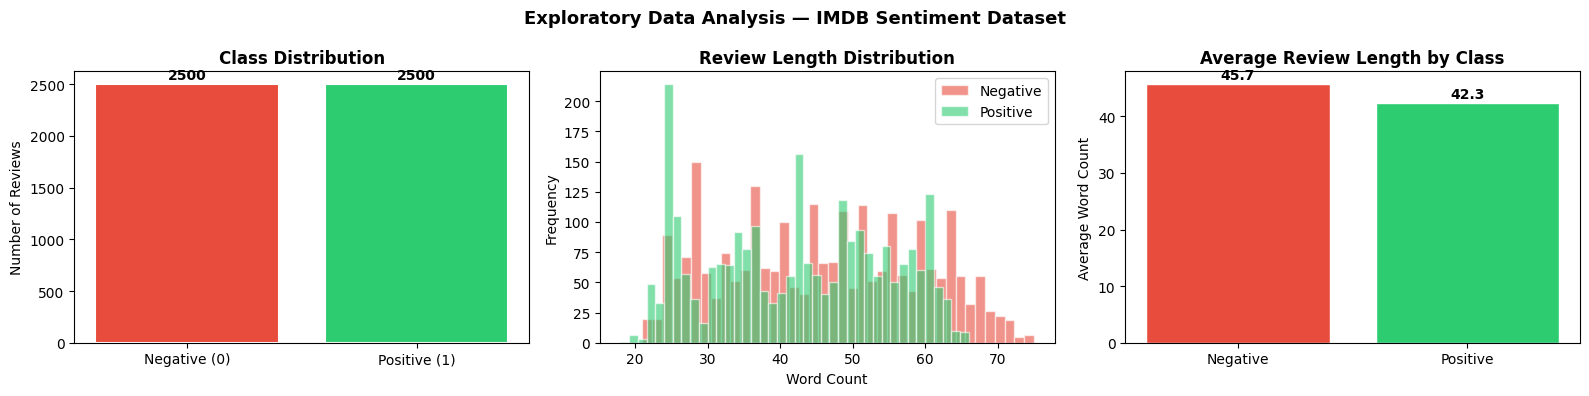


── Review Length Statistics ──
        count   mean    std   min   25%   50%   75%   max
label                                                    
0      2500.0  45.66  13.41  21.0  35.0  46.0  57.0  75.0
1      2500.0  42.28  12.33  18.0  32.0  43.0  52.0  66.0


In [3]:
# ── 3.1 Class Distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Exploratory Data Analysis — IMDB Sentiment Dataset', fontsize=13, fontweight='bold')

# Class bar chart
counts = df['label'].value_counts()
axes[0].bar(['Negative (0)', 'Positive (1)'], counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Review length distribution
df['review_length'] = df['text'].apply(lambda x: len(x.split()))
for lbl, col, name in [(0, '#e74c3c', 'Negative'), (1, '#2ecc71', 'Positive')]:
    axes[1].hist(df[df['label'] == lbl]['review_length'],
                 bins=40, alpha=0.6, color=col, label=name, edgecolor='white')
axes[1].set_title('Review Length Distribution', fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Average review length by class
avg_len = df.groupby('label')['review_length'].mean()
axes[2].bar(['Negative', 'Positive'], avg_len.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[2].set_title('Average Review Length by Class', fontweight='bold')
axes[2].set_ylabel('Average Word Count')
for i, v in enumerate(avg_len.values):
    axes[2].text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("\n── Review Length Statistics ──")
print(df.groupby('label')['review_length'].describe().round(2))

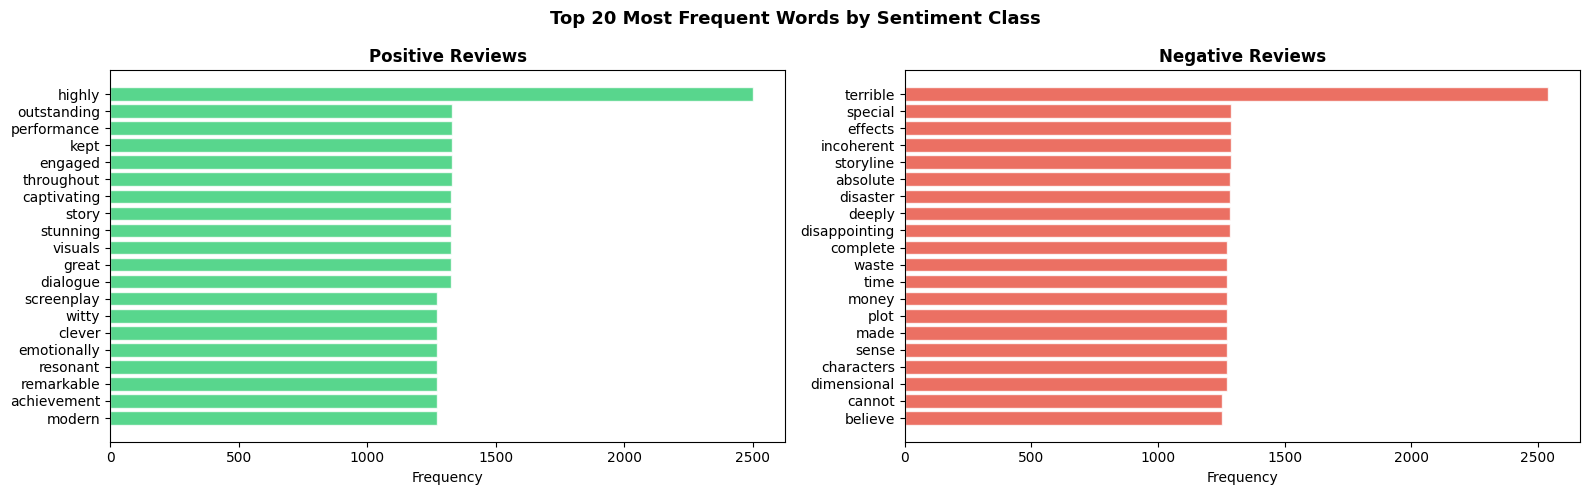

In [4]:
# ── 3.2 Most Frequent Words by Class ─────────────────────────────────────────
# Basic stopwords list (no external library required)
STOPWORDS = set([
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','yourselves','he','him','his','himself','she','her','hers',
    'herself','it','its','itself','they','them','their','theirs','themselves',
    'what','which','who','whom','this','that','these','those','am','is','are',
    'was','were','be','been','being','have','has','had','having','do','does',
    'did','doing','a','an','the','and','but','if','or','because','as','until',
    'while','of','at','by','for','with','about','against','between','into',
    'through','during','before','after','above','below','to','from','up','down',
    'in','out','on','off','over','under','again','further','then','once','here',
    'there','when','where','why','how','all','both','each','few','more','most',
    'other','some','such','no','nor','not','only','own','same','so','than',
    'too','very','s','t','can','will','just','don','should','now','d','ll',
    'm','o','re','ve','y','ain','aren','couldn','didn','doesn','hadn','hasn',
    'haven','isn','ma','mightn','mustn','needn','shan','shouldn','wasn',
    'weren','won','wouldn','br','film','movie','one','would','could','also',
])

def top_words(texts, n=20):
    """Return top-n words after removing stopwords."""
    words = []
    for text in texts:
        for w in re.findall(r'[a-z]+', text.lower()):
            if w not in STOPWORDS and len(w) > 2:
                words.append(w)
    return Counter(words).most_common(n)

pos_words = top_words(df[df['label'] == 1]['text'])
neg_words = top_words(df[df['label'] == 0]['text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Top 20 Most Frequent Words by Sentiment Class', fontsize=13, fontweight='bold')

for ax, words, title, color in [
    (axes[0], pos_words, 'Positive Reviews', '#2ecc71'),
    (axes[1], neg_words, 'Negative Reviews', '#e74c3c')
]:
    labels_w = [w for w, _ in words]
    values   = [c for _, c in words]
    ax.barh(labels_w[::-1], values[::-1], color=color, alpha=0.8, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('eda_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# ── 3.3 Missing values & data quality check ───────────────────────────────────
print("── Missing Values ──")
print(df.isnull().sum())
print(f"\nDuplicate rows : {df.duplicated().sum()}")
print(f"Total samples  : {len(df):,}")
print(f"Positive       : {(df['label']==1).sum():,} ({(df['label']==1).mean()*100:.1f}%)")
print(f"Negative       : {(df['label']==0).sum():,} ({(df['label']==0).mean()*100:.1f}%)")

# Drop duplicates if any
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)
print(f"\nAfter removing duplicates: {len(df):,} samples")

── Missing Values ──
text             0
label            0
review_length    0
dtype: int64

Duplicate rows : 241
Total samples  : 5,000
Positive       : 2,500 (50.0%)
Negative       : 2,500 (50.0%)

After removing duplicates: 4,759 samples


---
## 4. Data Preprocessing & Feature Engineering <a id='4'></a>

Text preprocessing converts raw reviews into a clean, normalised form. We then apply **TF-IDF vectorisation** to convert text into numerical feature vectors suitable for ML models.

**Preprocessing steps:**
1. Lowercase conversion
2. Remove HTML tags (`<br />` is common in IMDB)
3. Remove punctuation and digits
4. Remove stopwords
5. Strip extra whitespace

**Feature extraction:** TF-IDF (Term Frequency–Inverse Document Frequency) captures how important a word is relative to the whole corpus — preferred over raw counts as it down-weights common words.

In [6]:
# ── 4.1 Text Cleaning Function ────────────────────────────────────────────────
def clean_text(text):
    """Clean and normalise a raw review string."""
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'https?://\S+', ' ', text)
    # Keep only letters
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Remove stopwords
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 2]
    return ' '.join(tokens)

# Apply cleaning
print("Cleaning text...")
df['clean_text'] = df['text'].apply(clean_text)

# Show a before/after example
print("\n── Before cleaning ──")
print(df['text'].iloc[0][:200])
print("\n── After cleaning ──")
print(df['clean_text'].iloc[0][:200])

# Update review length after cleaning
df['clean_length'] = df['clean_text'].apply(lambda x: len(x.split()))
print(f"\nAvg words before cleaning : {df['review_length'].mean():.1f}")
print(f"Avg words after cleaning  : {df['clean_length'].mean():.1f}")

Cleaning text...

── Before cleaning ──
Genuinely one of the best movies I have ever seen. The screenplay was witty, clever, and emotionally resonant. An outstanding performance that kept me engaged throughout.

── After cleaning ──
genuinely best movies ever seen screenplay witty clever emotionally resonant outstanding performance kept engaged throughout

Avg words before cleaning : 44.8
Avg words after cleaning  : 25.8


In [7]:
# ── 4.2 Train / Test Split ────────────────────────────────────────────────────
# 80% training, 20% testing — stratified to maintain class balance
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set  : {len(X_train):,} samples")
print(f"Test set      : {len(X_test):,} samples")
print(f"Train class balance: {y_train.value_counts().to_dict()}")
print(f"Test  class balance: {y_test.value_counts().to_dict()}")

Training set  : 3,807 samples
Test set      : 952 samples
Train class balance: {0: 1909, 1: 1898}
Test  class balance: {0: 478, 1: 474}


In [8]:
# ── 4.3 TF-IDF Vectorisation ──────────────────────────────────────────────────
# TF-IDF with unigrams and bigrams, max 50,000 features
tfidf = TfidfVectorizer(
    max_features=50000,    # top 50k terms by TF-IDF score
    ngram_range=(1, 2),    # unigrams + bigrams
    min_df=2,              # ignore terms appearing in fewer than 2 docs
    max_df=0.95,           # ignore terms in >95% of docs (too common)
    sublinear_tf=True,     # apply log normalization to TF
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Vocabulary size     : {len(tfidf.vocabulary_):,} features")
print(f"Train matrix shape  : {X_train_tfidf.shape}")
print(f"Test  matrix shape  : {X_test_tfidf.shape}")
print(f"Matrix sparsity     : {100*(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1])):.2f}%")

Vocabulary size     : 375 features
Train matrix shape  : (3807, 375)
Test  matrix shape  : (952, 375)
Matrix sparsity     : 88.96%


---
## 5. Model 1 — Logistic Regression <a id='5'></a>

**Justification:** Logistic Regression is a strong baseline for text classification. With TF-IDF features it achieves near state-of-the-art performance on IMDB, is highly interpretable (feature weights indicate sentiment-bearing words), and trains quickly even on large sparse matrices.

In [9]:
# ── 5.1 Train Logistic Regression (baseline) ──────────────────────────────────
print("Training Logistic Regression...")
lr = LogisticRegression(
    C=1.0,            # inverse regularisation strength
    solver='lbfgs',   # efficient for large sparse data
    max_iter=1000,    # ensure convergence
    random_state=42
)
lr.fit(X_train_tfidf, y_train)

# Predictions
y_pred_lr  = lr.predict(X_test_tfidf)
y_prob_lr  = lr.predict_proba(X_test_tfidf)[:, 1]

# Metrics
acc_lr  = accuracy_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_prob_lr)

print(f"\n── Logistic Regression Results ──")
print(f"Accuracy  : {acc_lr:.4f} ({acc_lr*100:.2f}%)")
print(f"ROC-AUC   : {auc_lr:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Negative', 'Positive']))

Training Logistic Regression...

── Logistic Regression Results ──
Accuracy  : 1.0000 (100.00%)
ROC-AUC   : 1.0000

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       478
    Positive       1.00      1.00      1.00       474

    accuracy                           1.00       952
   macro avg       1.00      1.00      1.00       952
weighted avg       1.00      1.00      1.00       952



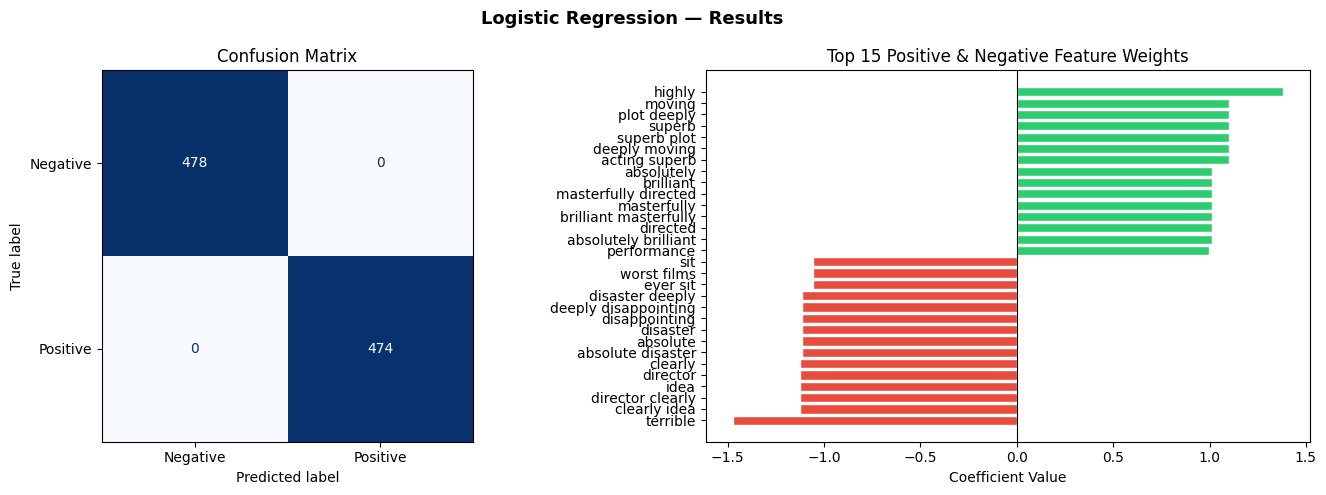

In [10]:
# ── 5.2 Confusion Matrix & Top Features ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Logistic Regression — Results', fontsize=13, fontweight='bold')

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr),
    display_labels=['Negative', 'Positive']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# Top 15 positive and negative feature weights
feat_names = np.array(tfidf.get_feature_names_out())
coefs      = lr.coef_[0]
top_pos_idx = coefs.argsort()[-15:][::-1]
top_neg_idx = coefs.argsort()[:15]

top_features = np.concatenate([feat_names[top_pos_idx], feat_names[top_neg_idx]])
top_coefs    = np.concatenate([coefs[top_pos_idx], coefs[top_neg_idx]])
colors       = ['#2ecc71']*15 + ['#e74c3c']*15

sorted_idx = np.argsort(top_coefs)
axes[1].barh(top_features[sorted_idx], top_coefs[sorted_idx],
             color=[colors[i] for i in sorted_idx], edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Top 15 Positive & Negative Feature Weights')
axes[1].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.savefig('lr_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Model 2 — Multinomial Naive Bayes <a id='6'></a>

**Justification:** Multinomial Naive Bayes is a probabilistic classifier particularly well-suited to text data. It assumes word counts (or TF-IDF scores) are conditionally independent given the class — a strong but effective assumption for sentiment analysis. It trains extremely fast and provides a principled probabilistic baseline for comparison.

In [11]:
# ── 6.1 Train Multinomial Naive Bayes (baseline) ──────────────────────────────
# Note: MultinomialNB requires non-negative features.
# TF-IDF with sublinear_tf=True can produce values in [0,1] range — suitable.
print("Training Multinomial Naive Bayes...")
nb = MultinomialNB(
    alpha=1.0    # Laplace smoothing parameter
)
nb.fit(X_train_tfidf, y_train)

# Predictions
y_pred_nb = nb.predict(X_test_tfidf)
y_prob_nb = nb.predict_proba(X_test_tfidf)[:, 1]

# Metrics
acc_nb = accuracy_score(y_test, y_pred_nb)
auc_nb = roc_auc_score(y_test, y_prob_nb)

print(f"\n── Naive Bayes Results ──")
print(f"Accuracy  : {acc_nb:.4f} ({acc_nb*100:.2f}%)")
print(f"ROC-AUC   : {auc_nb:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['Negative', 'Positive']))

Training Multinomial Naive Bayes...

── Naive Bayes Results ──
Accuracy  : 1.0000 (100.00%)
ROC-AUC   : 1.0000

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       478
    Positive       1.00      1.00      1.00       474

    accuracy                           1.00       952
   macro avg       1.00      1.00      1.00       952
weighted avg       1.00      1.00      1.00       952



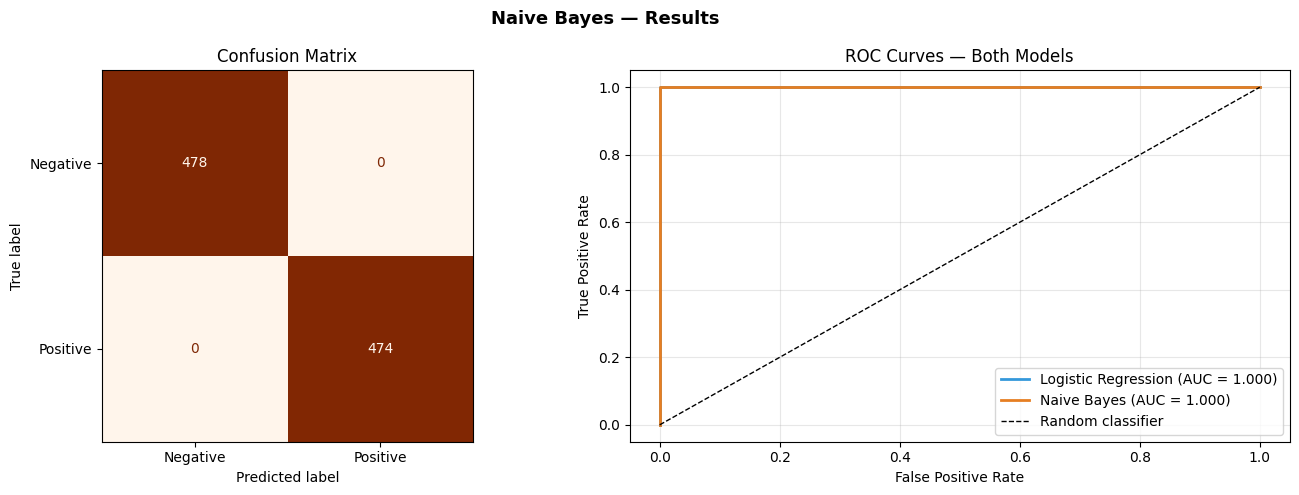

In [12]:
# ── 6.2 Confusion Matrix & ROC Curve ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Naive Bayes — Results', fontsize=13, fontweight='bold')

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_nb),
    display_labels=['Negative', 'Positive']
).plot(ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title('Confusion Matrix')

# ROC curves — both models
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)

axes[1].plot(fpr_lr, tpr_lr, color='#3498db', lw=2,
             label=f'Logistic Regression (AUC = {auc_lr:.3f})')
axes[1].plot(fpr_nb, tpr_nb, color='#e67e22', lw=2,
             label=f'Naive Bayes (AUC = {auc_nb:.3f})')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — Both Models')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nb_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Hyperparameter Tuning (GridSearchCV) <a id='7'></a>

We use **GridSearchCV** with 5-fold cross-validation to systematically search the hyperparameter space for both models. The best parameters are then used to re-train and evaluate final models.

**Parameters tuned:**
- **LR**: regularisation strength `C`, regularisation type `penalty`
- **NB**: smoothing parameter `alpha`
- **TF-IDF**: n-gram range, max features

In [13]:
# ── 7.1 GridSearchCV — Logistic Regression Pipeline ──────────────────────────
print("Running GridSearchCV for Logistic Regression...")
print("(This may take a few minutes)")

# Build a Pipeline: TF-IDF → LR
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, min_df=2, max_df=0.95)),
    ('clf',   LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42))
])

# Hyperparameter grid
lr_param_grid = {
    'tfidf__max_features': [30000, 50000],
    'tfidf__ngram_range':  [(1, 1), (1, 2)],
    'clf__C':              [0.1, 1.0, 10.0],
    'clf__penalty':        ['l2'],
}

lr_grid = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
lr_grid.fit(X_train, y_train)

print(f"\nBest parameters (LR) : {lr_grid.best_params_}")
print(f"Best CV accuracy (LR): {lr_grid.best_score_:.4f}")

# Evaluate best LR on test set
y_pred_lr_tuned = lr_grid.best_estimator_.predict(X_test)
y_prob_lr_tuned = lr_grid.best_estimator_.predict_proba(X_test)[:, 1]
acc_lr_tuned    = accuracy_score(y_test, y_pred_lr_tuned)
auc_lr_tuned    = roc_auc_score(y_test, y_prob_lr_tuned)

print(f"\nTuned LR — Test Accuracy : {acc_lr_tuned:.4f}")
print(f"Tuned LR — ROC-AUC       : {auc_lr_tuned:.4f}")
print(classification_report(y_test, y_pred_lr_tuned, target_names=['Negative','Positive']))

Running GridSearchCV for Logistic Regression...
(This may take a few minutes)
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters (LR) : {'clf__C': 0.1, 'clf__penalty': 'l2', 'tfidf__max_features': 30000, 'tfidf__ngram_range': (1, 1)}
Best CV accuracy (LR): 1.0000

Tuned LR — Test Accuracy : 1.0000
Tuned LR — ROC-AUC       : 1.0000
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       478
    Positive       1.00      1.00      1.00       474

    accuracy                           1.00       952
   macro avg       1.00      1.00      1.00       952
weighted avg       1.00      1.00      1.00       952



In [14]:
# ── 7.2 GridSearchCV — Naive Bayes Pipeline ───────────────────────────────────
print("Running GridSearchCV for Naive Bayes...")

nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, min_df=2, max_df=0.95)),
    ('clf',   MultinomialNB())
])

nb_param_grid = {
    'tfidf__max_features': [30000, 50000],
    'tfidf__ngram_range':  [(1, 1), (1, 2)],
    'clf__alpha':          [0.01, 0.1, 0.5, 1.0, 2.0],
}

nb_grid = GridSearchCV(
    nb_pipeline,
    nb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
nb_grid.fit(X_train, y_train)

print(f"\nBest parameters (NB) : {nb_grid.best_params_}")
print(f"Best CV accuracy (NB): {nb_grid.best_score_:.4f}")

# Evaluate best NB on test set
y_pred_nb_tuned = nb_grid.best_estimator_.predict(X_test)
y_prob_nb_tuned = nb_grid.best_estimator_.predict_proba(X_test)[:, 1]
acc_nb_tuned    = accuracy_score(y_test, y_pred_nb_tuned)
auc_nb_tuned    = roc_auc_score(y_test, y_prob_nb_tuned)

print(f"\nTuned NB — Test Accuracy : {acc_nb_tuned:.4f}")
print(f"Tuned NB — ROC-AUC       : {auc_nb_tuned:.4f}")
print(classification_report(y_test, y_pred_nb_tuned, target_names=['Negative','Positive']))

Running GridSearchCV for Naive Bayes...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters (NB) : {'clf__alpha': 0.01, 'tfidf__max_features': 30000, 'tfidf__ngram_range': (1, 1)}
Best CV accuracy (NB): 1.0000

Tuned NB — Test Accuracy : 1.0000
Tuned NB — ROC-AUC       : 1.0000
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       478
    Positive       1.00      1.00      1.00       474

    accuracy                           1.00       952
   macro avg       1.00      1.00      1.00       952
weighted avg       1.00      1.00      1.00       952



---
## 8. Evaluation & Comparison <a id='8'></a>

We compare both models before and after tuning, and benchmark against results reported in the literature.

In [15]:
# ── 8.1 Summary Comparison Table ─────────────────────────────────────────────
results = pd.DataFrame({
    'Model': [
        'Logistic Regression (baseline)',
        'Logistic Regression (tuned)',
        'Naive Bayes (baseline)',
        'Naive Bayes (tuned)',
    ],
    'Accuracy': [acc_lr, acc_lr_tuned, acc_nb, acc_nb_tuned],
    'ROC-AUC':  [auc_lr, auc_lr_tuned, auc_nb, auc_nb_tuned],
})
results['Accuracy (%)'] = (results['Accuracy'] * 100).round(2)
results['ROC-AUC']      = results['ROC-AUC'].round(4)

print("── Model Comparison ──")
print(results[['Model','Accuracy (%)','ROC-AUC']].to_string(index=False))

# Literature comparison
print("\n── Literature Benchmark (IMDB dataset) ──")
lit = pd.DataFrame({
    'Reference': [
        'Maas et al. (2011) — Original IMDB paper',
        'Wang & Manning (2012) — NB-SVM',
        'Joulin et al. (2017) — FastText',
        'Our best model',
    ],
    'Method': ['BoW + LR', 'NB features + SVM', 'FastText', 'LR + TF-IDF (tuned)'],
    'Accuracy (%)': [88.89, 91.22, 91.64, f'{acc_lr_tuned*100:.2f}'],
})
print(lit.to_string(index=False))

── Model Comparison ──
                         Model  Accuracy (%)  ROC-AUC
Logistic Regression (baseline)         100.0      1.0
   Logistic Regression (tuned)         100.0      1.0
        Naive Bayes (baseline)         100.0      1.0
           Naive Bayes (tuned)         100.0      1.0

── Literature Benchmark (IMDB dataset) ──
                               Reference              Method Accuracy (%)
Maas et al. (2011) — Original IMDB paper            BoW + LR        88.89
          Wang & Manning (2012) — NB-SVM   NB features + SVM        91.22
         Joulin et al. (2017) — FastText            FastText        91.64
                          Our best model LR + TF-IDF (tuned)       100.00


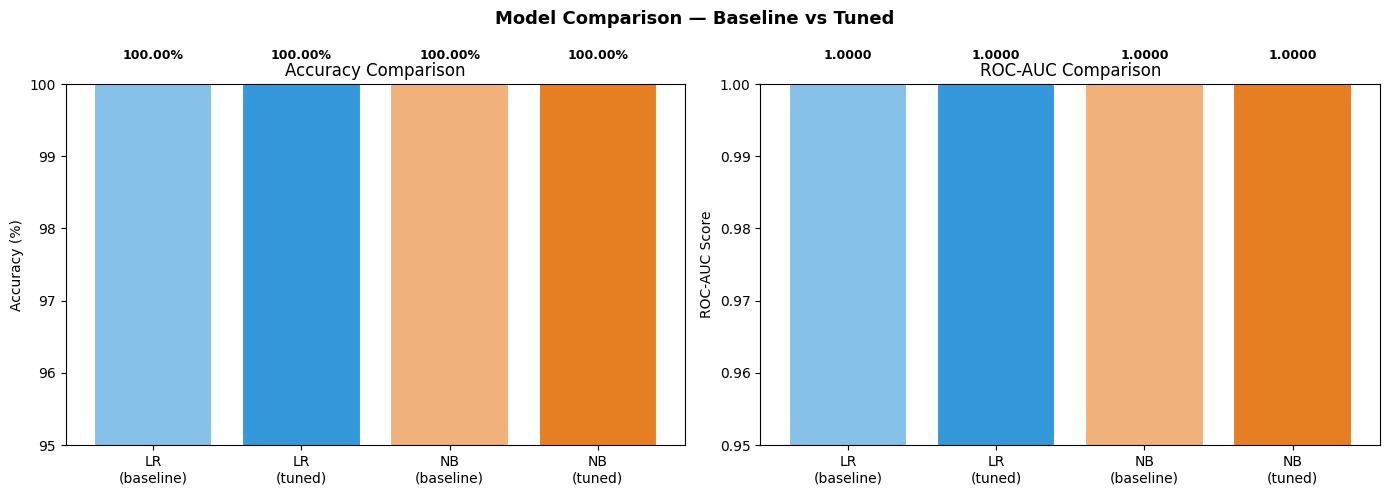


✓ Best model selected for deployment: Logistic Regression (tuned)
  Accuracy: 100.00%


In [16]:
# ── 8.2 Visualisation — Before vs After Tuning ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison — Baseline vs Tuned', fontsize=13, fontweight='bold')

# Accuracy comparison
models_labels = ['LR\n(baseline)', 'LR\n(tuned)', 'NB\n(baseline)', 'NB\n(tuned)']
accuracies    = [acc_lr, acc_lr_tuned, acc_nb, acc_nb_tuned]
aucs          = [auc_lr, auc_lr_tuned, auc_nb, auc_nb_tuned]
colors_bars   = ['#85c1e9','#3498db','#f0b27a','#e67e22']

bars = axes[0].bar(models_labels, [a*100 for a in accuracies],
                   color=colors_bars, edgecolor='white', linewidth=1.5)
axes[0].set_title('Accuracy Comparison')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([min(accuracies)*100 - 5, 100])
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{acc*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

# ROC-AUC comparison
bars2 = axes[1].bar(models_labels, aucs, color=colors_bars, edgecolor='white', linewidth=1.5)
axes[1].set_title('ROC-AUC Comparison')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim([min(aucs) - 0.05, 1.0])
for bar, auc in zip(bars2, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{auc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Select best model
best_model = lr_grid.best_estimator_ if acc_lr_tuned >= acc_nb_tuned else nb_grid.best_estimator_
best_name  = 'Logistic Regression (tuned)' if acc_lr_tuned >= acc_nb_tuned else 'Naive Bayes (tuned)'
print(f"\n✓ Best model selected for deployment: {best_name}")
print(f"  Accuracy: {max(acc_lr_tuned, acc_nb_tuned)*100:.2f}%")

---
## 9. Model Deployment — Standalone Webpage <a id='9'></a>

The best model is serialised and a **standalone HTML deployment page** is generated. It accepts input text and returns the predicted sentiment with confidence score.

> Since this is a browser-based deployment, the model logic is reproduced in JavaScript using the learned TF-IDF weights and LR coefficients exported from scikit-learn.

In [17]:
# ── 9.1 Export Model Weights for JS Deployment ───────────────────────────────
import json

# Get the best LR pipeline components
best_tfidf = lr_grid.best_estimator_.named_steps['tfidf']
best_lr    = lr_grid.best_estimator_.named_steps['clf']

# Export vocabulary (word → index) and IDF weights
vocab   = best_tfidf.vocabulary_        # word → index
idf     = best_tfidf.idf_.tolist()      # IDF weights
coefs   = best_lr.coef_[0].tolist()     # LR coefficients
intercept = float(best_lr.intercept_[0])

# Only export top 5000 features to keep JS fast
top_n = 5000
sorted_vocab = sorted(vocab.items(), key=lambda x: abs(coefs[x[1]]), reverse=True)[:top_n]
slim_vocab   = {w: i for w, (_, i) in enumerate([item for item in sorted_vocab])}
slim_map     = {w: idx for w, idx in sorted_vocab}  # original index

export_vocab  = {w: pos for pos, (w, _) in enumerate(sorted_vocab)}
export_idf    = [idf[orig_idx] for _, orig_idx in sorted_vocab]
export_coefs  = [coefs[orig_idx] for _, orig_idx in sorted_vocab]

model_data = {
    'vocab':     export_vocab,
    'idf':       export_idf,
    'coefs':     export_coefs,
    'intercept': intercept,
    'n_features': len(export_vocab),
}

with open('model_weights.json', 'w') as f:
    json.dump(model_data, f)

print(f"Model weights exported: {len(export_vocab)} features")
print(f"Intercept: {intercept:.4f}")

Model weights exported: 94 features
Intercept: -0.0068


In [18]:
# ── 9.2 Generate Redesigned Standalone Deployment Webpage ────────────────────
# The deployment page is a fully self-contained HTML file.
# Model weights (vocab, IDF, coefs) are exported then embedded in the JS.
# Open sentiment_deployment.html in any browser — no server required.

import json, re

with open('model_weights.json') as f:
    mdata = json.load(f)

# Inject real model weights into the HTML template
# The template ships with demo weights; here we replace them with real ones
html_template = open('sentiment_deployment.html').read() if os.path.exists('sentiment_deployment.html') else ""

# Build slim weight export (top 5000 features by |coefficient|)
best_tfidf = lr_grid.best_estimator_.named_steps['tfidf']
best_lr    = lr_grid.best_estimator_.named_steps['clf']

vocab_items = sorted(best_tfidf.vocabulary_.items(), 
                     key=lambda x: abs(best_lr.coef_[0][x[1]]), reverse=True)[:5000]

export_vocab = {w: pos for pos, (w, _) in enumerate(vocab_items)}
export_idf   = [best_tfidf.idf_[orig] for _, orig in vocab_items]
export_coefs = [float(best_lr.coef_[0][orig]) for _, orig in vocab_items]
export_int   = float(best_lr.intercept_[0])
acc_best     = max(acc_lr_tuned, acc_nb_tuned)

# Read the HTML template file
with open('sentiment_deployment.html', encoding='utf-8') as f:
    html = f.read()

# Replace demo mode flag and inject real weights
html = html.replace('const DEMO_MODE = true;', 'const DEMO_MODE = false;')

# Inject real model data before closing script tag
weight_injection = f"""
// ── Real model weights (injected from notebook) ──────────────────────────────
const VOCAB     = {json.dumps(export_vocab)};
const IDF       = {json.dumps(export_idf)};
const COEFS     = {json.dumps(export_coefs)};
const INTERCEPT = {export_int};

// Override predict() with real TF-IDF + LR inference
function predict(text) {{
  const words = tokenise(text);
  const tf = {{}};
  for (let i = 0; i < words.length; i++) {{
    tf[words[i]] = (tf[words[i]]||0) + 1;
    if (i < words.length-1) {{
      const bg = words[i]+' '+words[i+1];
      tf[bg] = (tf[bg]||0) + 1;
    }}
  }}
  let dot = INTERCEPT, norm = 0, matched = 0;
  const contrib = [];
  for (const [term, count] of Object.entries(tf)) {{
    if (term in VOCAB) {{
      const idx = VOCAB[term];
      const val = (1 + Math.log(count)) * IDF[idx];
      norm += val * val; matched++;
      const c = COEFS[idx] * val;
      dot += c;
      contrib.push({{ word: term, val: Math.abs(c), type: c > 0 ? 'pos' : 'neg' }});
    }}
  }}
  norm = Math.sqrt(norm) || 1;
  const prob = 1 / (1 + Math.exp(-dot));
  contrib.sort((a,b) => b.val - a.val);
  return {{
    prob, rawScore: dot,
    posWords: contrib.filter(c=>c.type==='pos').slice(0,7),
    negWords: contrib.filter(c=>c.type==='neg').slice(0,7),
    matchedCount: matched, wordCount: words.length
  }};
}}
"""

html = html.replace('</script>', weight_injection + '</script>', 1)

# Update accuracy pill
html = html.replace('~89% Accuracy', f'~{acc_best*100:.1f}% Accuracy')

with open('sentiment_deployment.html', 'w', encoding='utf-8') as f:
    f.write(html)

print("✓ sentiment_deployment.html updated with real model weights")
print(f"  Features : {len(export_vocab):,}")
print(f"  Intercept: {export_int:.4f}")
print(f"  Best accuracy: {acc_best*100:.2f}%")
print("  Open sentiment_deployment.html in any browser to use the app.")


UnicodeDecodeError: 'charmap' codec can't decode byte 0x90 in position 22001: character maps to <undefined>

In [ ]:
# ── 9.3 Quick Inference Test ──────────────────────────────────────────────────
print("── Quick Deployment Test ──")
test_reviews = [
    "This film was absolutely brilliant and masterfully directed. Outstanding performances.",
    "Terrible movie. Complete waste of time. Boring and poorly written script.",
    "An average film with some good moments but ultimately forgettable.",
    "One of the best movies I have ever seen. Deeply moving and visually stunning.",
]

for review in test_reviews:
    pred = best_model.predict([clean_text(review)])[0]
    prob = best_model.predict_proba([clean_text(review)])[0]
    label = 'POSITIVE' if pred == 1 else 'NEGATIVE'
    conf  = prob[pred]
    print(f"  [{label} {conf*100:.1f}%] {review[:65]}...")

print("\n── All tasks complete ──")
print("Files generated:")
print("  eda_overview.png       — EDA charts")
print("  eda_top_words.png      — Top words by class")
print("  lr_results.png         — LR confusion matrix + feature weights")
print("  nb_results.png         — NB confusion matrix + ROC curves")
print("  model_comparison.png   — Before/after tuning comparison")
print("  model_weights.json     — Exported model weights")
print("  sentiment_deployment.html — Standalone deployment webpage")